In [ ]:
!pip install roboflow ultralytics

from google.colab import drive
drive.mount('/content/drive')

⏳ Підключення Google Диску...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="9R3HxruX7rJJlbc6rGqA")
project = rf.workspace("fpv-w9u7u").project("military-lyxbx-0x48c")
version = project.version(1)
dataset = version.download("yolo26")

yaml_path = os.path.join(dataset.location, "data.yaml")
print(f"done. config: {yaml_path}")

loading Roboflow workspace...
loading Roboflow project...
done. config: /content/Military-1/data.yaml


In [ ]:
from ultralytics import YOLO

print("init")
model = YOLO('yolov8n.pt')

print("begining")
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=720,
    batch=8,
    project="/content/military_fpv",
    name="train_run",
    device=0
)
print("done")

init
begining
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Military-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_run-3, nbs=64

In [ ]:
import os
import glob
import shutil

print("best model search")

search_path = "/content/military_fpv/**/weights/best.pt"
found_models = glob.glob(search_path, recursive=True)

if found_models:
    latest_model = max(found_models, key=os.path.getctime)
    print(f"found file: {latest_model}")

    drive_folder = "/content/drive/MyDrive/YOLO_Military_Models"
    os.makedirs(drive_folder, exist_ok=True)

    destination = os.path.join(drive_folder, "best_model_v1.pt")

    shutil.copy(latest_model, destination)
    print(f"saved on google drive:")
    print(f"{destination}")
else:
    print("file best.pt was not found")

best model search
found file: /content/military_fpv/train_run-3/weights/best.pt
saved on google drive:
/content/drive/MyDrive/YOLO_Military_Models/best_model_v1.pt


loading model
test: /content/Military-1/valid/images/29_mp4-1_jpg.rf.9cb89df3fe8287a99953e2b81bc87a03.jpg

image 1/1 /content/Military-1/valid/images/29_mp4-1_jpg.rf.9cb89df3fe8287a99953e2b81bc87a03.jpg: 384x640 2 persons, 10.5ms
Speed: 15.9ms preprocess, 10.5ms inference, 9.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/inference/image_test


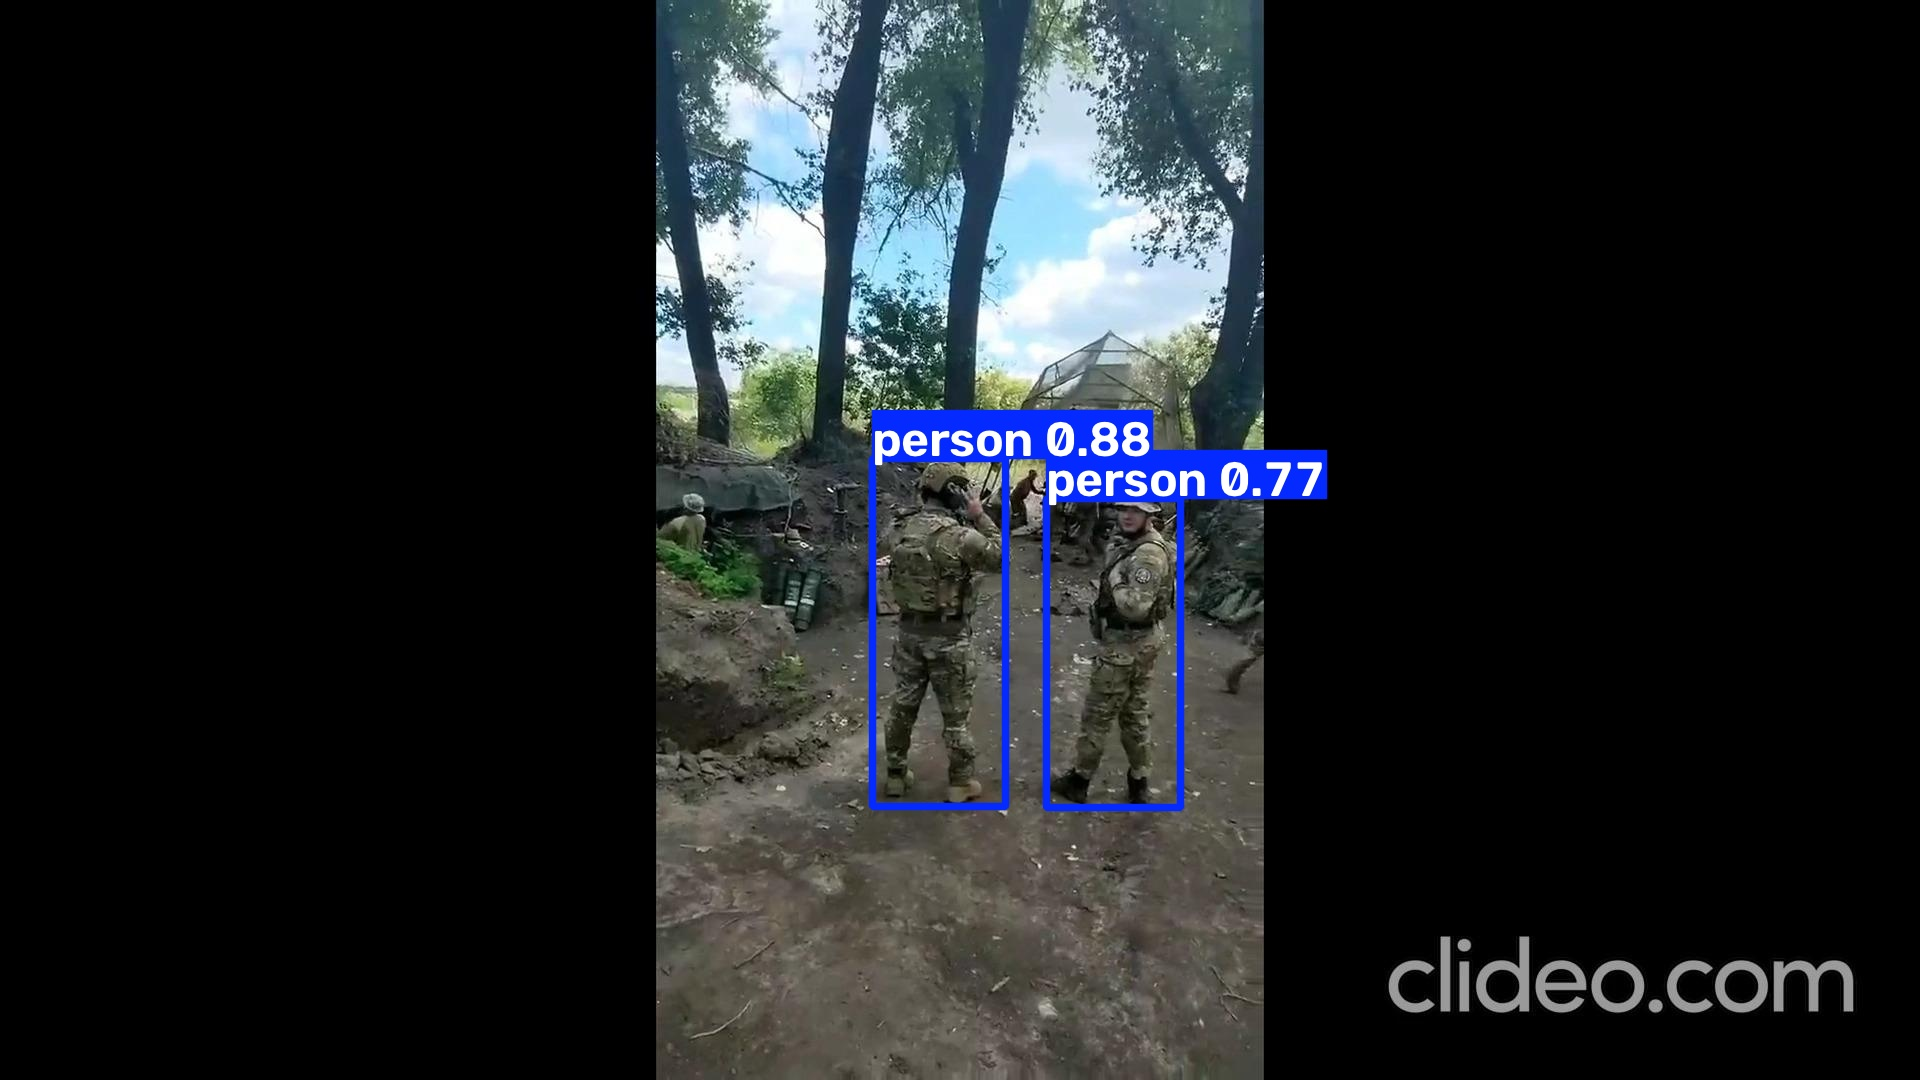

In [ ]:
import os
import glob
from IPython.display import Image, display
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/YOLO_Military_Models/best_model_v1.pt"

if os.path.exists(model_path):
    print("loading model")
    model = YOLO(model_path)

    test_images = glob.glob("/content/**/valid/images/*.jpg", recursive=True)

    if test_images:
        img_path = test_images[0]
        print(f"test: {img_path}")

        results = model.predict(
            source=img_path,
            conf=0.5,
            save=True,
            project="/content/inference",
            name="image_test",
            exist_ok=True
        )

        result_img_path = os.path.join("/content/inference/image_test", os.path.basename(img_path))
        display(Image(filename=result_img_path, width=800))
    else:
        print("test images was not found in valid.")
else:
    print(f"model was not found in: {model_path}")

In [ ]:
import os
import shutil
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/YOLO_Military_Models/best_model_v1.pt"
input_video_path = "/content/drive/MyDrive/YOLO_Military_Models/test_video.mp4"

if not os.path.exists(input_video_path):
    print(f"video was not found: {input_video_path}")
elif not os.path.exists(model_path):
    print(f"model was not found: {model_path}")
else:
    print("begining")
    model = YOLO(model_path)

    results = model.predict(
        source=input_video_path,
        conf=0.4,
        save=True,
        project="/content/inference",
        name="video_test",
        exist_ok=True
    )

    print("saving to google drive")
    video_name = os.path.basename(input_video_path)
    name_without_ext = os.path.splitext(video_name)[0]

    possible_outputs = [
        f"/content/inference/video_test/{name_without_ext}.avi",
        f"/content/inference/video_test/{video_name}"
    ]

    final_output_path = next((path for path in possible_outputs if os.path.exists(path)), None)

    if final_output_path:
        drive_output_path = f"/content/drive/MyDrive/YOLO_Military_Models/result_{name_without_ext}.avi"
        shutil.copy(final_output_path, drive_output_path)
        print("saved on drive")
        print(f" {drive_output_path}")
    else:
        print("could not find final file")

begining

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1218) /content/drive/MyDrive/YOLO_Military_Models/test_video.mp4: 384x640 (no detections), 6.1ms
video 1/1 (frame 2/1218) /content/drive/MyDrive/YOLO_Military_Models/test_video.mp4: 384x640 (no detections), 9.5ms
video 1/1 (frame 3/1218) /content/drive/MyDrive/YOLO_Military_Models/test_video.mp4: 384x640 (no detections), 8.1ms
video 1/1 (frame 4/1218) /content/drive/MyDrive/YOLO_Military_Models/test_video.mp4: 384x640 1 person,